# DeepVox Phase 2 — ASR (Codec2 → Texte Français)

**Notebook Kaggle** — GPU T4/P100

Pipeline :
1. Installer les dépendances (pycodec2, praatio)
2. Charger Common Voice FR depuis Kaggle
3. Preprocessing : MP3 → WAV 8kHz → Codec2 frames
4. Entraîner le modèle ASR BiLSTM + CTC
5. Évaluer WER / CER

Architecture : BiLSTM 3 couches, hidden=384, 9.1M params

Entrée : frames Codec2 (48 features / 40ms)  
Sortie : texte français (caractères)

## Historique des runs

| Run | MAX_SAMPLES | MAX_EPOCHS | CER test | Doc |
|---|---|---|---|---|
| #1 | 20 000 | 30 | 71.2 % | `docs/12_retour_experience_phase2_run1.md` |
| #2 | 80 000 | 50 | en cours | — |

## 0. Configuration du run

In [2]:
# ============================================================
# CONFIGURATION DU RUN — modifier ici pour chaque expérience
# ============================================================
RUN_NAME = "run2_80k"
MAX_SAMPLES = 80_000       # Run #1: 20_000, Run #2: 80_000
MAX_EPOCHS = 50            # Run #1: 30, Run #2: 50
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
PATIENCE = 7               # Run #1: 5, Run #2: 7 (plus de données = convergence plus lente)
MAX_DURATION_S = 12.0
NUM_WORKERS = 0             # Kaggle: 0 pour éviter les erreurs multiprocessing
# ============================================================
print(f"Run: {RUN_NAME}")
print(f"MAX_SAMPLES={MAX_SAMPLES:,}, MAX_EPOCHS={MAX_EPOCHS}, BATCH={BATCH_SIZE}")
print(f"LR={LEARNING_RATE}, PATIENCE={PATIENCE}")

Run: run2_80k
MAX_SAMPLES=80,000, MAX_EPOCHS=50, BATCH=32
LR=0.0003, PATIENCE=7


In [3]:
# Installer les dépendances manquantes sur Kaggle
!pip install -q pycodec2 praatio librosa soundfile

import os
import sys
import torch
print(f'PyTorch {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 6.6 MB/s eta 0:00:00
PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
! rm -rf  /kaggle/working/DeepVox

In [5]:
# Cloner le repo DeepVox

!git clone https://github.com/oumar5/DeepVox.git 2>/dev/null || echo 'Already cloned'
sys.path.insert(0, 'DeepVox/src')

from deepvox.codec2.encoder import encode_pcm, unpack_frames, SAMPLE_RATE, SAMPLES_PER_FRAME
from deepvox.data.text import VOCAB_SIZE, BLANK_IDX, encode, decode, decode_ctc, normalize_text
from deepvox.models.ctc_asr import CTCASR
from deepvox.eval.wer import wer, cer

print(f'Vocab size: {VOCAB_SIZE}')
print('Imports OK')

Vocab size: 49
Imports OK


## 1. Charger les données Common Voice FR

Le dataset est ajouté comme "Input" dans Kaggle.
On utilise `find` (bash) au lieu de `rglob` (Python) pour scanner les 99k sous-dossiers rapidement.

In [6]:
import subprocess
from pathlib import Path
import pandas as pd

BASE = '/kaggle/input/datasets/fredrelec/common-voice-french-21-0-2025'

# Trouver le train.tsv (liste pour supporter les espaces dans les chemins)
tsv_result = subprocess.run(
    ['find', BASE, '-name', 'train.tsv', '-maxdepth', '6'],
    capture_output=True, text=True
)
tsv_path = tsv_result.stdout.strip().split('\n')[0]
print(f'TSV: {tsv_path}')

df = pd.read_csv(tsv_path, sep='\t', usecols=['path', 'sentence'])
print(f'Entrées train: {len(df):,}')
print(df.head())

# Indexer les MP3 (liste pour supporter les espaces)
print('\nIndexation des MP3 (patience ~60s)...')
mp3_result = subprocess.run(
    ['find', BASE, '-name', '*.mp3', '-maxdepth', '6'],
    capture_output=True, text=True
)
mp3_lines = mp3_result.stdout.strip().split('\n')
all_mp3s = {Path(p).name: p for p in mp3_lines if p}
print(f'MP3 indexés: {len(all_mp3s):,}')

TSV: /kaggle/input/datasets/fredrelec/common-voice-french-21-0-2025/14765036117 14765036125/cv-corpus-21.0-2025-03-14/fr/train.tsv
Entrées train: 586,763
                           path  \
0  common_voice_fr_19623614.mp3   
1  common_voice_fr_19623617.mp3   
2  common_voice_fr_19623619.mp3   
3  common_voice_fr_19623621.mp3   
4  common_voice_fr_19623624.mp3   

                                            sentence  
0  De plus, le cisaillement des vents avec l'alti...  
1  Nul autre canot ne sillonnait les eaux du fleuve.  
2  Après la formation médicale, il rejoint l'armé...  
3  Ils déplaçaient en charge nominale et à à plei...  
4           L'utilisation de la magie reste limitée.  

Indexation des MP3 (patience ~60s)...
MP3 indexés: 839,978


## 2. Preprocessing : MP3 → Codec2 frames + tokenized text

In [7]:
import librosa
import numpy as np
from tqdm.auto import tqdm

def process_sample(mp3_path, sentence, max_duration_s=MAX_DURATION_S):
    """MP3 → (Codec2 features, char_ids) ou None si filtré."""
    try:
        audio, _ = librosa.load(str(mp3_path), sr=SAMPLE_RATE, mono=True)
    except Exception:
        return None
    
    if len(audio) / SAMPLE_RATE > max_duration_s or len(audio) / SAMPLE_RATE < 0.5:
        return None
    
    text = normalize_text(sentence)
    if not text:
        return None
    
    pcm = (audio * 32767).astype(np.int16)
    frames = encode_pcm(pcm)
    feats = unpack_frames(frames)  # (T, 48)
    char_ids = encode(text)
    
    if len(feats) < len(char_ids):
        return None
    
    return feats, char_ids, text

In [8]:
# Déjà indexé dans all_mp3s ci-dessus
print(f'Clips MP3 disponibles: {len(all_mp3s):,}')

Clips MP3 disponibles: 839,978


In [9]:
samples = []
skipped = 0

for _, row in tqdm(df.iterrows(), total=min(len(df), MAX_SAMPLES * 3), desc='Processing'):
    if len(samples) >= MAX_SAMPLES:
        break
    
    mp3_name = row['path']
    if mp3_name not in all_mp3s:
        skipped += 1
        continue
    
    result = process_sample(all_mp3s[mp3_name], row['sentence'])
    if result is None:
        skipped += 1
        continue
    
    samples.append(result)

print(f'\nSamples valides : {len(samples):,}')
print(f'Skipped : {skipped:,}')

# Stats
frame_lens = [len(s[0]) for s in samples]
char_lens = [len(s[1]) for s in samples]
print(f'Frames/sample : min={min(frame_lens)}, max={max(frame_lens)}, mean={np.mean(frame_lens):.0f}')
print(f'Chars/sample : min={min(char_lens)}, max={max(char_lens)}, mean={np.mean(char_lens):.0f}')

Processing:   0%|          | 0/240000 [00:00<?, ?it/s]


Samples valides : 80,000
Skipped : 9
Frames/sample : min=28, max=294, mean=136
Chars/sample : min=3, max=200, mean=59


## 3. Dataset + DataLoader

In [10]:
from torch.utils.data import Dataset, DataLoader
import random

class ASRDatasetKaggle(Dataset):
    def __init__(self, samples):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        feats, char_ids, text = self.samples[idx]
        return (
            torch.from_numpy(feats).float(),
            torch.tensor(char_ids, dtype=torch.long),
            len(feats),
            len(char_ids),
        )


def ctc_collate(batch):
    feats, chars, f_lens, c_lens = zip(*batch)
    max_T = max(f_lens)
    max_L = max(c_lens)
    B = len(batch)
    
    feats_pad = torch.zeros(B, max_T, 48)
    chars_pad = torch.zeros(B, max_L, dtype=torch.long)
    
    for i in range(B):
        feats_pad[i, :feats[i].size(0)] = feats[i]
        chars_pad[i, :chars[i].size(0)] = chars[i]
    
    return feats_pad, chars_pad, torch.tensor(f_lens), torch.tensor(c_lens)


# Split 90/5/5
random.seed(42)
random.shuffle(samples)
n = len(samples)
n_train = int(n * 0.9)
n_dev = int(n * 0.05)

train_ds = ASRDatasetKaggle(samples[:n_train])
dev_ds = ASRDatasetKaggle(samples[n_train:n_train+n_dev])
test_ds = ASRDatasetKaggle(samples[n_train+n_dev:])

print(f'Train: {len(train_ds)}, Dev: {len(dev_ds)}, Test: {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=ctc_collate, num_workers=NUM_WORKERS)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate, num_workers=NUM_WORKERS)

Train: 72000, Dev: 4000, Test: 4000


## 4. Modèle + Entraînement

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

model = CTCASR()
model = model.to(device)
print(f'Params: {model.count_parameters():,}')
print(f'Size (float32): {model.count_parameters() * 4 / 1e6:.1f} MB')

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = torch.nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)

Device: cuda
Params: 9,112,625
Size (float32): 36.5 MB


In [12]:
import time

SAVE_DIR = Path(f'/kaggle/working/{RUN_NAME}')
SAVE_DIR.mkdir(exist_ok=True)

best_dev_cer = float('inf')
no_improve = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    
    # Train
    model.train()
    train_loss = 0
    n_batches = 0
    
    for feats, chars, f_lens, c_lens in tqdm(train_loader, desc=f'Epoch {epoch}', leave=False):
        feats = feats.to(device)
        chars = chars.to(device)
        f_lens = f_lens.to(device)
        c_lens = c_lens.to(device)
        
        log_probs = model(feats).transpose(0, 1)  # (T, B, V)
        loss = criterion(log_probs, chars, f_lens, c_lens)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        train_loss += loss.item()
        n_batches += 1
    
    train_loss /= max(n_batches, 1)
    
    # Eval
    model.eval()
    all_refs, all_hyps = [], []
    
    with torch.no_grad():
        for feats, chars, f_lens, c_lens in dev_loader:
            feats = feats.to(device)
            preds = model.greedy_decode(feats)
            
            for i, pred_ids in enumerate(preds):
                pred_ids = pred_ids[:f_lens[i].item()]
                hyp = decode_ctc(pred_ids)
                ref = decode(chars[i, :c_lens[i].item()].tolist())
                all_hyps.append(hyp)
                all_refs.append(ref)
    
    dev_wer_val = wer(all_refs, all_hyps)
    dev_cer_val = cer(all_refs, all_hyps)
    scheduler.step(dev_cer_val)
    lr = optimizer.param_groups[0]['lr']
    dt = time.time() - t0
    
    history.append({
        'epoch': epoch, 'train_loss': train_loss,
        'dev_wer': dev_wer_val, 'dev_cer': dev_cer_val, 'lr': lr,
    })
    
    print(f'Epoch {epoch:02d} | loss={train_loss:.4f} | WER={dev_wer_val:.3f} CER={dev_cer_val:.3f} | lr={lr:.1e} | {dt:.0f}s')
    
    # Show 2 examples
    for j in range(min(2, len(all_refs))):
        print(f'  REF: {all_refs[j][:80]}')
        print(f'  HYP: {all_hyps[j][:80]}')
        print()
    
    # Periodic checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save(model.state_dict(), SAVE_DIR / f'checkpoint_epoch{epoch}.pt')
        print(f'  Periodic checkpoint saved (epoch {epoch})')
    
    # Early stopping
    if dev_cer_val < best_dev_cer:
        best_dev_cer = dev_cer_val
        no_improve = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_asr.pt')
        print(f'  Saved best (CER={dev_cer_val:.4f})')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'  Early stopping at epoch {epoch}')
            break

print(f'\nBest dev CER: {best_dev_cer:.4f}')

Epoch 1:   0%|          | 0/2250 [00:00<?, ?it/s]

Epoch 01 | loss=2.9210 | WER=1.000 CER=0.865 | lr=3.0e-04 | 438s
  REF: la mère de geng yanyi n'est autre que la sœur de l'impératrice rende
  HYP: leeeeeeeeeeeeea

  REF: il symbolise l'histoire des deux guerres mondiales sur les déchirements de l'als
  HYP: l eeeeeeeeeeeeeeea

  Saved best (CER=0.8654)


Epoch 2:   0%|          | 0/2250 [00:00<?, ?it/s]

Epoch 02 | loss=2.7226 | WER=1.325 CER=0.734 | lr=3.0e-04 | 455s
  REF: la mère de geng yanyi n'est autre que la sœur de l'impératrice rende
  HYP: il e e e e e e e e e e e e ee ai

  REF: il symbolise l'histoire des deux guerres mondiales sur les déchirements de l'als
  HYP: le e e e e e e e e e e e e e e e ao

  Saved best (CER=0.7345)


Epoch 3:   0%|          | 0/2250 [00:00<?, ?it/s]

...

Epoch 48 | loss=1.8640 | WER=0.936 CER=0.576 | lr=7.5e-05 | 456s
  REF: la mère de geng yanyi n'est autre que la sœur de l'impératrice rende
  HYP: lamae dege madie est outepolason da tarre e ceteeliite

  REF: il symbolise l'histoire des deux guerres mondiales sur les déchirements de l'als
  HYP: il fere estoi e dégarmentgile sur les définent de lasesesale



Epoch 49:   0%|          | 0/2250 [00:00<?, ?it/s]

Epoch 49 | loss=1.8513 | WER=0.944 CER=0.569 | lr=7.5e-05 | 457s
  REF: la mère de geng yanyi n'est autre que la sœur de l'impératrice rende
  HYP: lamae dege mabie est outepolation de darer e te teteninie

  REF: il symbolise l'histoire des deux guerres mondiales sur les déchirements de l'als
  HYP: il ferale destoie de damentgile sur les déccinent de lasatane

  Saved best (CER=0.5688)


Epoch 50:   0%|          | 0/2250 [00:00<?, ?it/s]

Epoch 50 | loss=1.8443 | WER=0.948 CER=0.568 | lr=7.5e-05 | 457s
  REF: la mère de geng yanyi n'est autre que la sœur de l'impératrice rende
  HYP: lamae dege madise est outepolasion de tarrer e ceteeminite

  REF: il symbolise l'histoire des deux guerres mondiales sur les déchirements de l'als
  HYP: il serai destoi de dament gile sur les décinent de laseesane

  Periodic checkpoint saved (epoch 50)
  Saved best (CER=0.5685)

Best dev CER: 0.5685


## 5. Courbes d'apprentissage

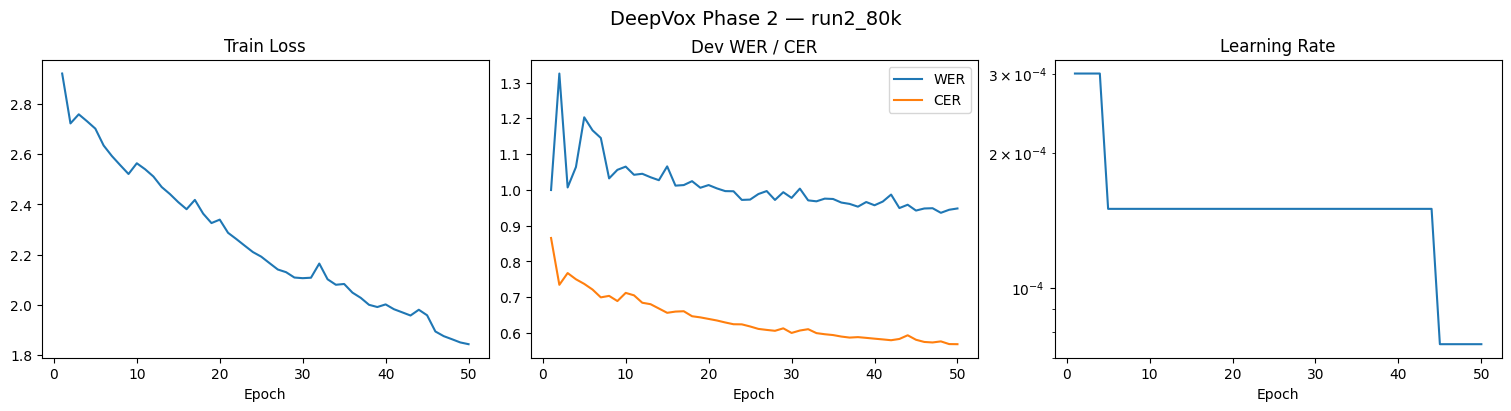

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

epochs_hist = [h['epoch'] for h in history]

axes[0].plot(epochs_hist, [h['train_loss'] for h in history])
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_hist, [h['dev_wer'] for h in history], label='WER')
axes[1].plot(epochs_hist, [h['dev_cer'] for h in history], label='CER')
axes[1].set_title('Dev WER / CER')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(epochs_hist, [h['lr'] for h in history])
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')

fig.suptitle(f'DeepVox Phase 2 — {RUN_NAME}', fontsize=14)
plt.savefig(f'/kaggle/working/{RUN_NAME}_training_curves.png', dpi=150)
plt.show()

## 6. Evaluation finale sur test set

In [14]:
# Charger le meilleur modèle
model.load_state_dict(torch.load(SAVE_DIR / 'best_asr.pt', map_location=device))
model.eval()

all_refs, all_hyps = [], []

with torch.no_grad():
    for feats, chars, f_lens, c_lens in tqdm(test_loader, desc='Test'):
        feats = feats.to(device)
        preds = model.greedy_decode(feats)
        for i, pred_ids in enumerate(preds):
            pred_ids = pred_ids[:f_lens[i].item()]
            all_hyps.append(decode_ctc(pred_ids))
            all_refs.append(decode(chars[i, :c_lens[i].item()].tolist()))

test_wer = wer(all_refs, all_hyps)
test_cer = cer(all_refs, all_hyps)

print(f'=== Test Results ({RUN_NAME}) ===')
print(f'WER: {test_wer:.4f} ({test_wer*100:.1f}%)')
print(f'CER: {test_cer:.4f} ({test_cer*100:.1f}%)')
print(f'Samples: {len(all_refs)}')
print()

# Exemples qualitatifs
print('=== Exemples ===')
indices = random.sample(range(len(all_refs)), min(10, len(all_refs)))
for idx in indices:
    print(f'REF: {all_refs[idx]}')
    print(f'HYP: {all_hyps[idx]}')
    print()

Test:   0%|          | 0/125 [00:00<?, ?it/s]

=== Test Results (run2_80k) ===
WER: 0.9496 (95.0%)
CER: 0.5687 (56.9%)
Samples: 4000

=== Exemples ===
REF: l'île relève de l'état de pernambouc au brésil
HYP: mas lie reproee de letar de caron couqe on prolele

REF: c'est une politique publique qui se rattache à la politique culturelle
HYP: c'est one ati pe pu pan en tasen la latique tesle

REF: c'est l'usure de la pompe récupératrice d'huile qui était cause de l'échec
HYP: cete iur de lapom e ce latricidetrité ou de lecie

REF: cependant il est remplacé en octobre par christophe canioni en raison d'une possible inéligibilité
HYP: cette aali de emate deto a parcretasagan en réniee parsude de leligiée

REF: elle se rencontre dans les états de colima et de jalisco
HYP: elle se rencontre dans la lépale commie et la carito

REF: il se déplace au sud de l'anticyclone subtropicale pris dans les alizés
HYP: il se dapa o mosui de lentiique là sopropilal ri dans les bai

REF: on obtient le mercure par grillage du cinabre
HYP: conotin de cuuru

In [15]:
# Sauvegarder le modèle final
save_path = f'/kaggle/working/{RUN_NAME}_model.pt'
torch.save(model.state_dict(), save_path)
print(f'Modèle sauvegardé ({model.count_parameters():,} params)')
print(f'Taille : {os.path.getsize(save_path) / 1e6:.1f} MB')
print(f'Run: {RUN_NAME} terminé')

Modèle sauvegardé (9,112,625 params)
Taille : 36.5 MB
Run: run2_80k terminé
